Разработка модели прогнозирования цен на бриллианты на основе их характеристик

Установим необходимые библиотекм

In [1]:
!pip install scikit-learn

In [2]:
!pip install scipy

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns

from matplotlib import pyplot as plt
from scipy import stats 

In [4]:
sns.set_theme(style='whitegrid')

Проанализируем цены на бриллианты (изучим зависимости и корреляции)

In [5]:
diamond_price = pd.read_csv('../data/DiamondsPrices2022.csv')
diamond_price.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Проведем EDA

Есть ненужный столбец, который нужно удалить

In [6]:
diamond_price = diamond_price.drop(["Unnamed: 0"],axis=1)
diamond_price.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Этот набор данных содержит цены и другие характеристики почти 54 000 бриллиантов.

Содержание


**price**: цена в долларах США ($ 32 6--$18 823)

**carat**: вес бриллианта в каратах (0,2-5,01)

**cut**: качество огранки (Fair-честная, Good-Хорошая, Very Good-Очень хорошая, premium-Премиум, Ideal-Идеальная)

**color**: цвет бриллианта, от J (худший) до D (лучший)

**clarity**: чистота измерение того, насколько чист бриллиант (I1 (худший), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (лучший))

**x**: длина в мм (0--10,74)

**y**: ширина  в мм (0--58,9)

**z**: глубина в мм (0--31,8)

**depth**: глубина, % : высота бриллианта, измеренная от оправы до стола, деленная на его средний диаметр по краю.

**table**: данные % ширины вершины алмаза относительно самой широкой точки (43--95)

Посмотрим на описание данного датасета

In [7]:
diamond_price.describe()

,carat,depth,table,price,x,y,z
count,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000
mean,0.797935,61.749322,57.457251,3932.734294,5.731158,5.734526,3.538730
std,0.473999,1.432626,2.234549,3989.338447,1.121730,1.142103,0.705679
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Этот набор данных содержит цены и другие характеристики почти 53 943 бриллиантов.

Посмотрим на наличие пропусков

In [8]:
diamond_price.isna().mean()

carat      0.0
cut        0.0
color      0.0
clarity    0.0
depth      0.0
table      0.0
price      0.0
x          0.0
y          0.0
z          0.0
dtype: float64

Можно сделать вывод, что пропусков нет

Проведем анализ NaN вхождений

In [9]:
diamond_price.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

В данном наборе данных NaN значений нет

Определим категориальные и числовые признаки

In [10]:
diamond_price.dtypes

carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Выделим эти признаки  и вкатегориальных признаков рставим только уникальные

In [11]:
numerical_columns = diamond_price.select_dtypes('number')
categorical_columns = diamond_price.select_dtypes('O')
for i in categorical_columns.columns:
    print(categorical_columns[i].unique())
['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
['E' 'I' 'J' 'H' 'F' 'G' 'D']
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


<StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str
<StringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str
<StringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str


C:\Users\SERGEY\AppData\Local\Temp\ipykernel_15040\745566525.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = diamond_price.select_dtypes('O')


['SI2SI1VS1VS2VVS2VVS1I1IF']

Визуализируем распределение всех категориальных признаков

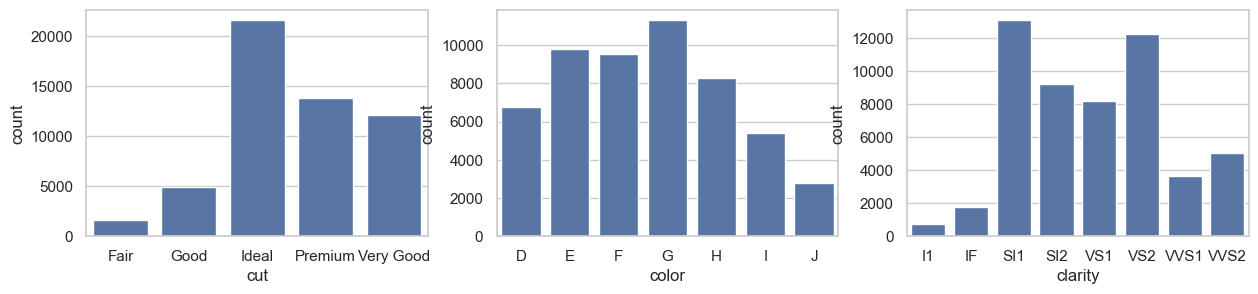

In [12]:
k = 1
plt.figure(figsize=(15, 10))
for c in categorical_columns.columns:
    plt.subplot(3, 3, k)
    sns.countplot(x=diamond_price[c].sort_values())
    k+=1

Визуализируем распределение  всех числовых признаков

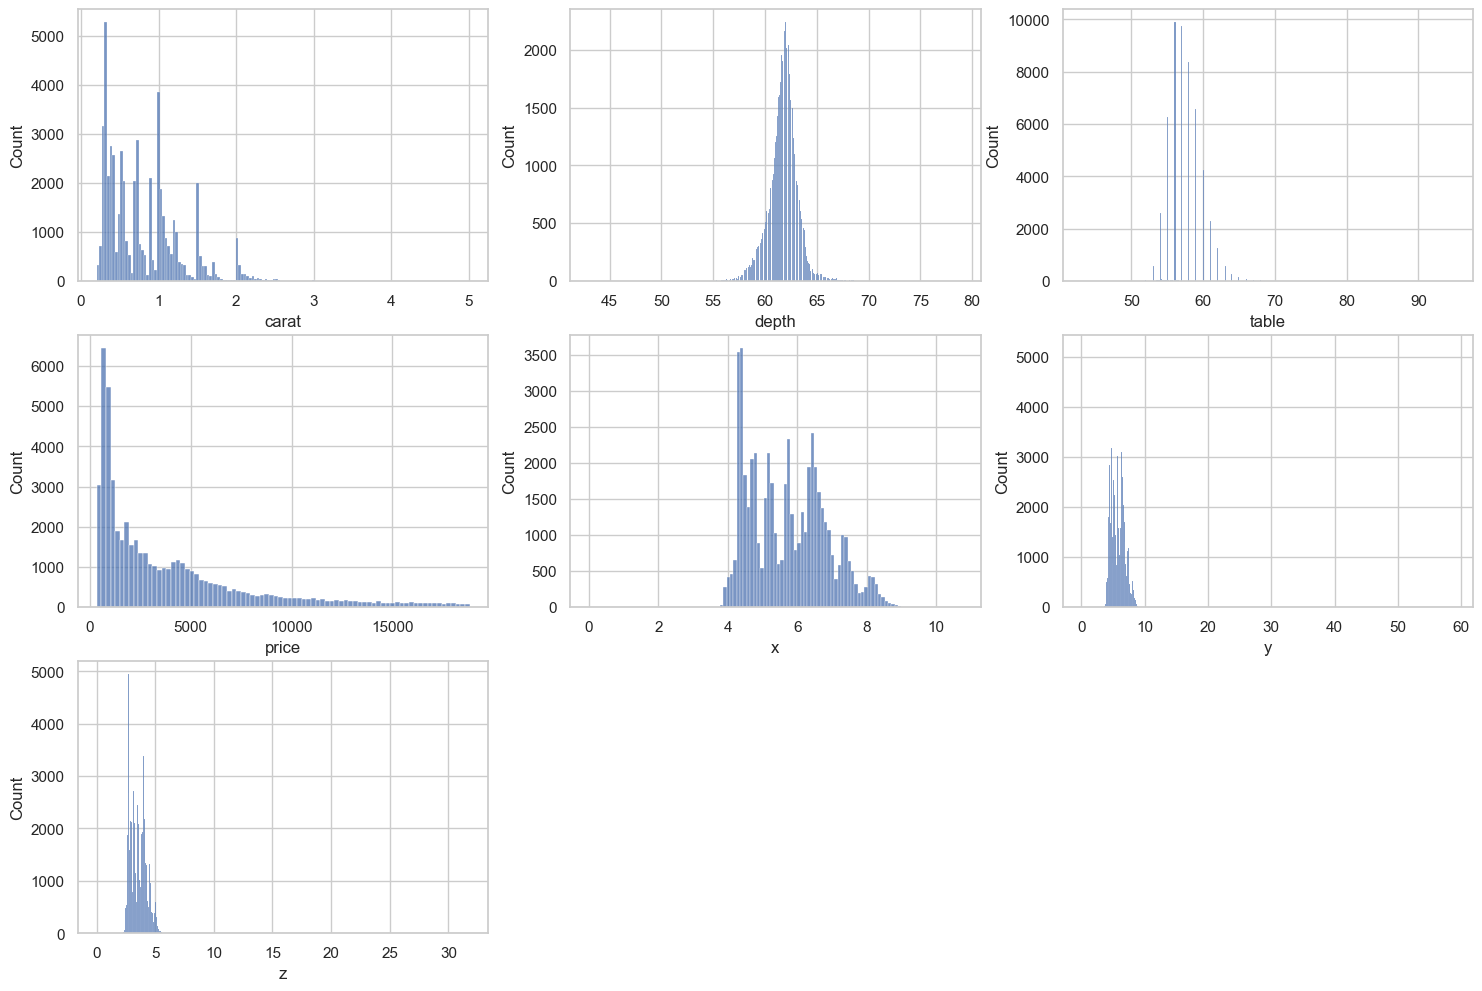

In [13]:
numerical_columns = diamond_price.select_dtypes('number')
k = 1
plt.figure(figsize=(18, 12))
for i in numerical_columns.columns:
    plt.subplot(3, 3, k)
    sns.histplot(x = diamond_price[i])
    k+=1

Теперь посмотрим на наличие выбросов по всем числовым признакам

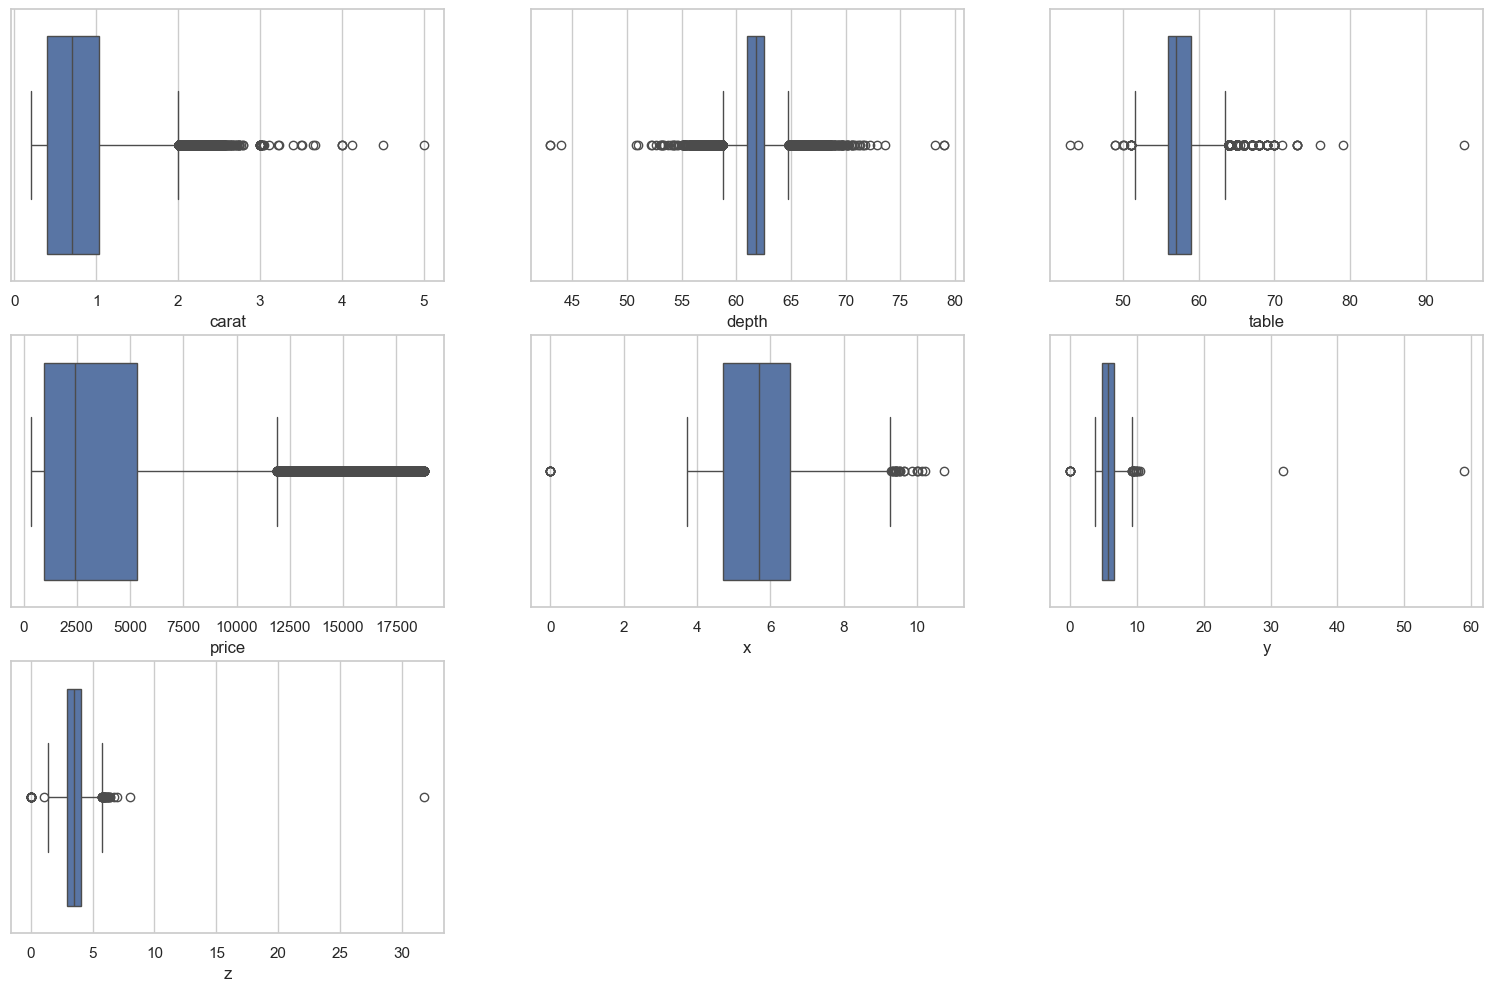

In [14]:
k = 1
plt.figure(figsize=(19, 12))
for i in numerical_columns.columns:
    plt.subplot(3, 3, k)
    sns.boxplot(x=diamond_price[i])
    k+=1

Z-score дает возможность посчитать велечину отклонения от среднего и таким образом, его можно использовать для обнаружения выбросов. Возьмем данное значение больше и меньше 3

In [15]:
# Определяем числовые колонки из вашего датафрейма
num_cols = diamond_price.select_dtypes('number')

# Фильтруем выбросы по Z-score
diamond_price = diamond_price[(np.abs(stats.zscore(num_cols)) < 3).all(axis=1)]

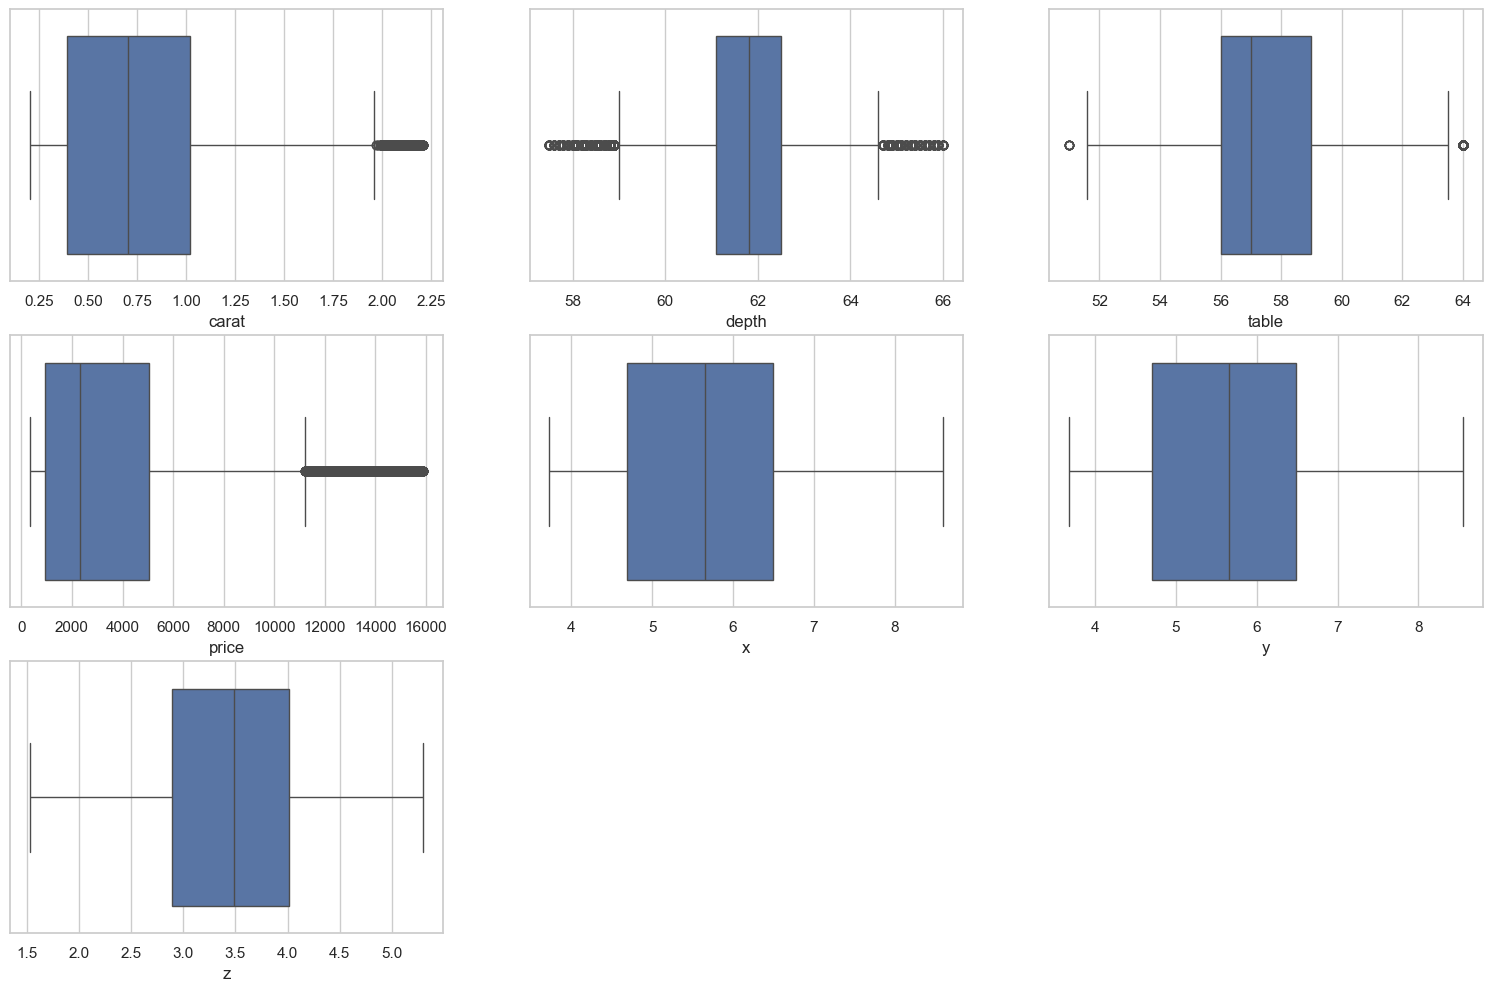

In [16]:
num_cols = diamond_price.select_dtypes('number')
i = 1
plt.figure(figsize=(19, 12))
for c in num_cols.columns:
    plt.subplot(3, 3, i)
    sns.boxplot(x=diamond_price[c])
    i+=1

Создадим корреляционную матрицу

In [17]:
diamond_price.corr(numeric_only=True)

,carat,depth,table,price,x,y,z
carat,1.000000,0.026984,0.187202,0.922409,0.982153,0.981279,0.981179
depth,0.026984,1.000000,-0.279897,-0.001882,-0.022920,-0.025340,0.090190
table,0.187202,-0.279897,1.000000,0.131667,0.194316,0.189214,0.160187
price,0.922409,-0.001882,0.131667,1.000000,0.890451,0.891716,0.887339
x,0.982153,-0.022920,0.194316,0.890451,1.000000,0.998634,0.992605
y,0.981279,-0.025340,0.189214,0.891716,0.998634,1.000000,0.992308
z,0.981179,0.090190,0.160187,0.887339,0.992605,0.992308,1.000000


Построим тепловую карту зависимости цены бриллиантов от его характеристик


Text(0.5, 1.0, 'Тепловая карта зависимости цены бриллиантов от его характеристик')

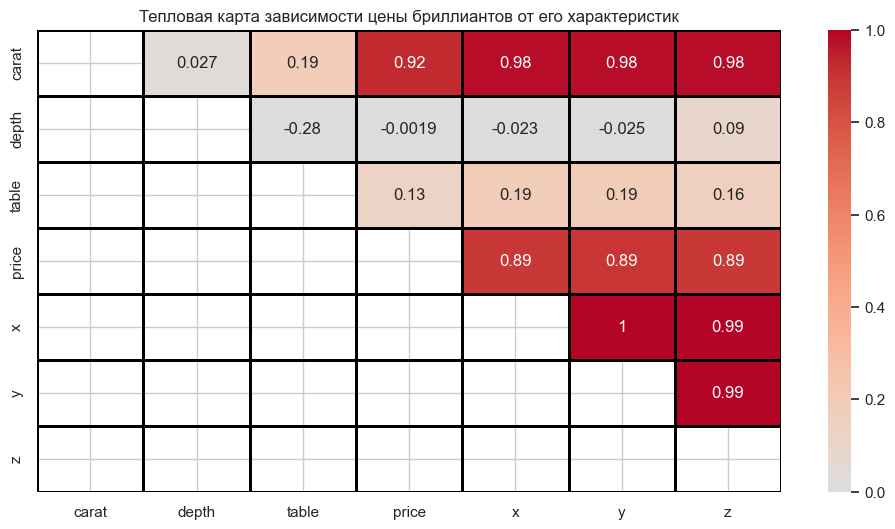

In [18]:
matrix = np.tril(diamond_price.corr(numeric_only=True))
plt.figure(figsize=(12,6))
sns.heatmap(diamond_price.corr(numeric_only=True), annot=True, fmt='.2g', vmin=0, vmax=1, center=0, cmap='coolwarm', linewidths=1, linecolor='black', mask=matrix)
plt.title('Тепловая карта зависимости цены бриллиантов от его характеристик')

Анализ тепловой карты корреляционной таблицы показывает, что цены бриллиантов в основном зависят от массы бриллианта (carat) и от его геометрических размеров (x,y.z).
Также наблюдается зависимость цены от глубины (depth). В то же время тепловая карта не показывае зависимости цены от таких характеристик как огранка (cut),цвет(color) и чистота (clarity).

array([[<Axes: xlabel='carat', ylabel='carat'>,
        <Axes: xlabel='depth', ylabel='carat'>,
        <Axes: xlabel='table', ylabel='carat'>,
        <Axes: xlabel='price', ylabel='carat'>,
        <Axes: xlabel='x', ylabel='carat'>,
        <Axes: xlabel='y', ylabel='carat'>,
        <Axes: xlabel='z', ylabel='carat'>],
       [<Axes: xlabel='carat', ylabel='depth'>,
        <Axes: xlabel='depth', ylabel='depth'>,
        <Axes: xlabel='table', ylabel='depth'>,
        <Axes: xlabel='price', ylabel='depth'>,
        <Axes: xlabel='x', ylabel='depth'>,
        <Axes: xlabel='y', ylabel='depth'>,
        <Axes: xlabel='z', ylabel='depth'>],
       [<Axes: xlabel='carat', ylabel='table'>,
        <Axes: xlabel='depth', ylabel='table'>,
        <Axes: xlabel='table', ylabel='table'>,
        <Axes: xlabel='price', ylabel='table'>,
        <Axes: xlabel='x', ylabel='table'>,
        <Axes: xlabel='y', ylabel='table'>,
        <Axes: xlabel='z', ylabel='table'>],
       [<Axes: xlabel='ca

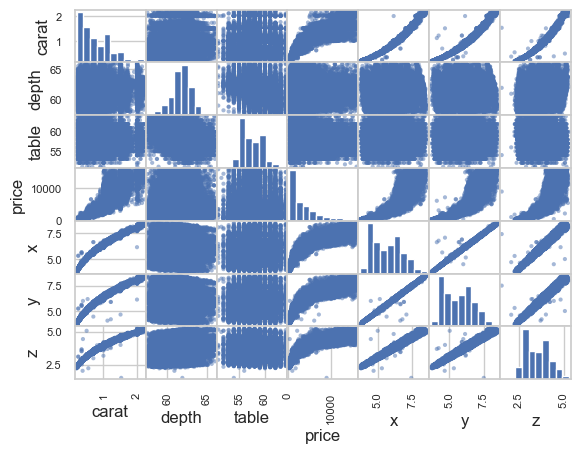

In [19]:
pd.plotting.scatter_matrix(diamond_price)

Исследуем теперь влияние каждого признака на цену в отдельности

Изучим влияние веса бриллианта на его цену

In [20]:
diamond_carat_price =diamond_price[['carat', 'price']]
diamond_carat_price.head(10)

,carat,price
0,0.23,326
1,0.21,326
3,0.29,334
4,0.31,335
5,0.24,336
6,0.24,336
7,0.26,337
8,0.22,337
9,0.23,338
10,0.30,339


Text(0.5, 1.0, 'Диаграмма рассеяния цены бриллиантов в зависимости от их веса')

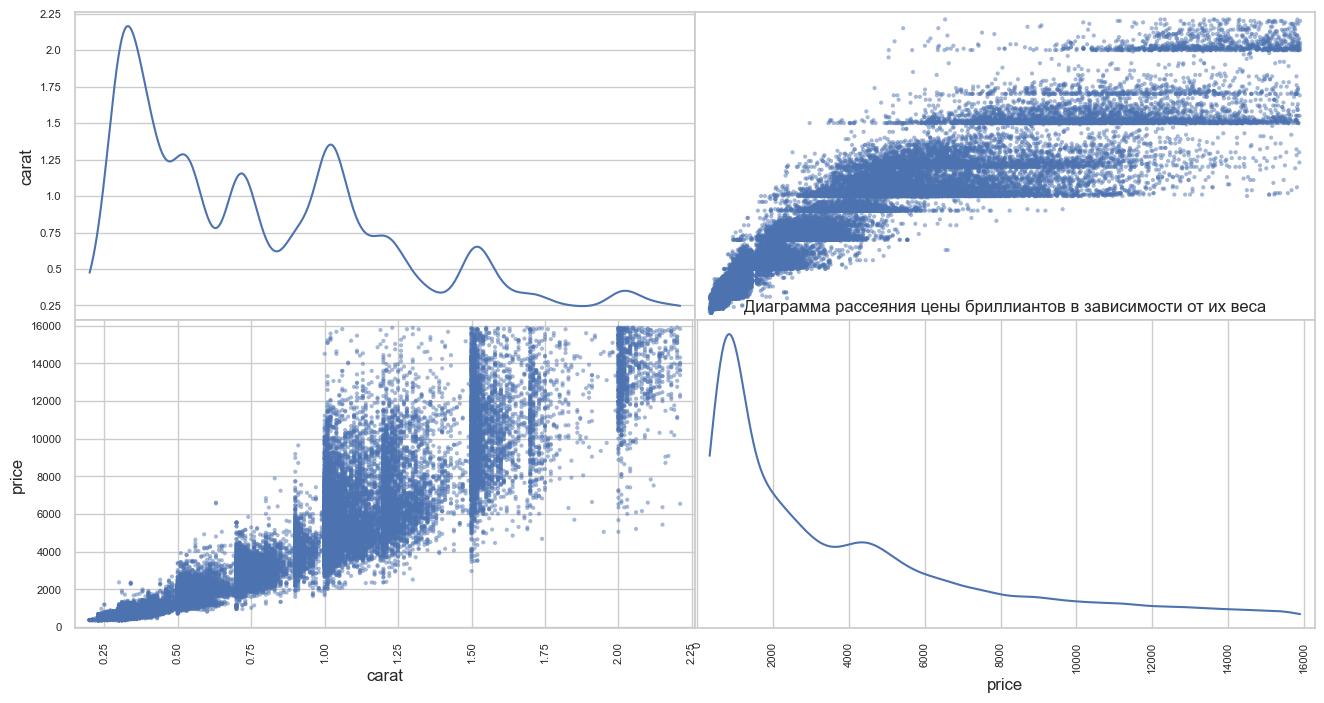

In [21]:
pd.plotting.scatter_matrix(diamond_carat_price, diagonal='kde', figsize=(16,8))
plt.title('Диаграмма рассеяния цены бриллиантов в зависимости от их веса')

Мы получили матрицы рассеяния с графиками плотности по диагонали.Хорошо заметна корреляция цены с весом бриллианта. На графиках также заметно большое количество выбросов. Для более точного количественного
анализа даной взаимосвязи построим bar.plot

In [22]:
diamond_carat_price.carat.value_counts()

carat
0.30    2592
0.31    2242
1.01    2182
0.70    1907
0.32    1837
        ... 
1.96       2
1.99       2
1.97       2
1.92       2
1.93       1
Name: count, Length: 202, dtype: int64

In [23]:
diamond_carat_price.carat.value_counts(bins = 4)

(0.197, 0.702]    26862
(0.702, 1.205]    17152
(1.205, 1.707]     6165
(1.707, 2.21]      1414
Name: count, dtype: int64

Text(0, 0.5, 'Масса в каратах')

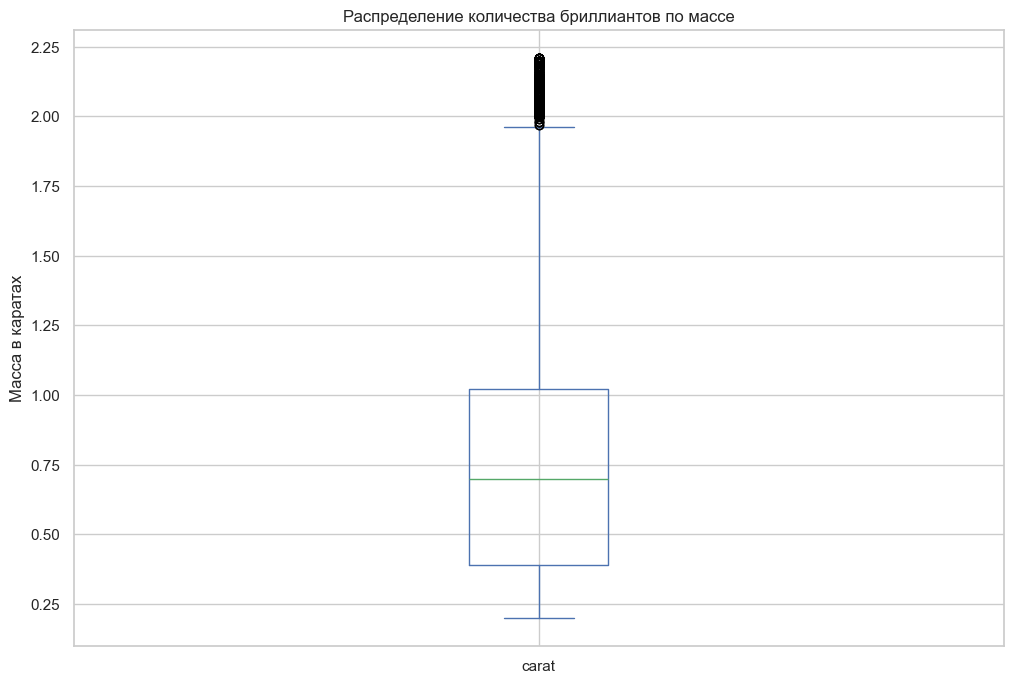

In [24]:
diamond_carat_price.carat.plot.box(figsize= (12, 8))
plt. title('Распределение количества бриллиантов по массе')
plt.ylabel('Масса в каратах')

In [25]:
Q1 = diamond_carat_price.carat.quantile(0.25)
Q3 =diamond_carat_price.carat.quantile(0.75)

IQR = Q3-Q1
Outlier_upper_boundary = Q3 + 1.5*IQR

print('Q1 =', Q1)
print('Q3 =', Q3)
print('IQR =', IQR)
print("Верняя граница ящика =", Outlier_upper_boundary)

Q1 = 0.39
Q3 = 1.02
IQR = 0.63
Верняя граница ящика = 1.965


Изучая "ящик с усами" можно сказать, что размер основной массы бриллиантов лежит в диапазоне от 0,4 карат до 1,04 карат. При этом мы имеем относительно большое количество
выбросов с размерами превышающими 2,0 карата которые оказывают существенное влияние на цену и не позволяют посчитать среднюю цену отдельного бриллианта """

In [26]:
sns.set_theme(style='darkgrid')

Рассмотрим зависимость цены от огранки

Text(0.5, 0, 'Огранка (cut)')

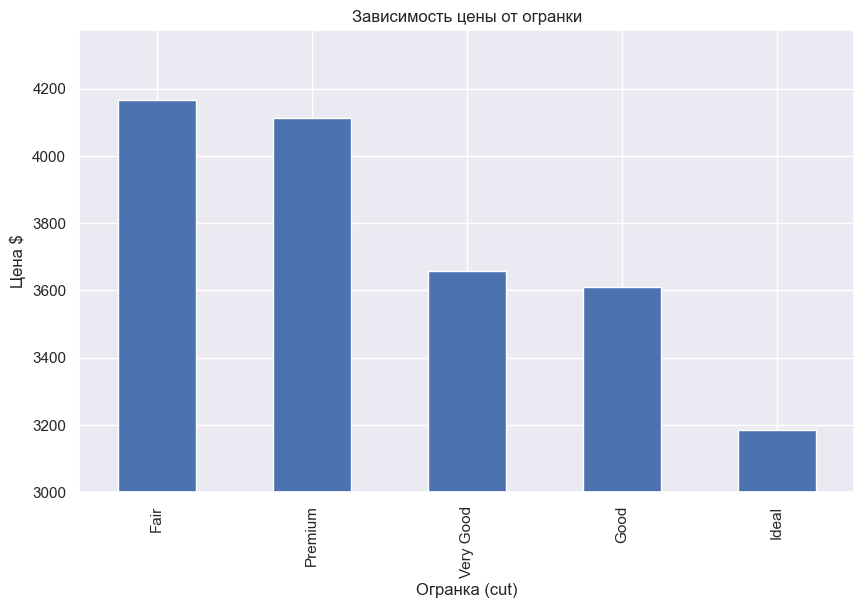

In [27]:
diamond_price.groupby('cut').price.mean().sort_values(ascending = False).plot.bar(figsize=(10,6))
plt.ylim(3000)
plt.title('Зависимость цены от огранки')
plt.ylabel('Цена $')
plt.xlabel('Огранка (cut)')

На данном графике мы можем наблюдать зависимость цены от огранки и цена колеблется от 3000 до 4600

Посмотрим на распределение количнства бриллиантов по огранке

In [28]:
diamond_cut = diamond_price.cut.value_counts()
diamond_cut

cut
Ideal        21120
Premium      13267
Very Good    11763
Good          4523
Fair           920
Name: count, dtype: int64

Text(0, 0.5, 'Огранка')

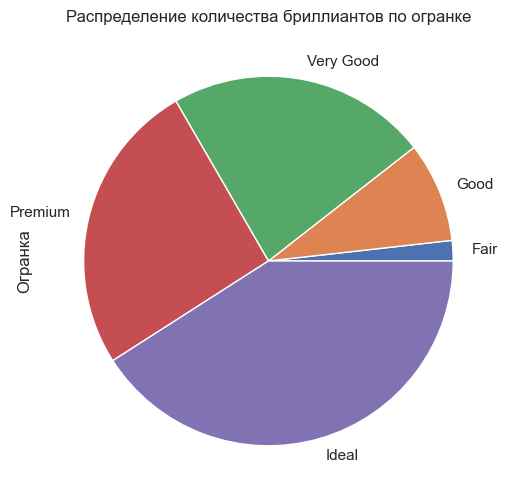

In [29]:
diamond_cut.sort_values(ascending = True).plot.pie(figsize=(14,6))
plt.title('Распределение количества бриллиантов по огранке')
plt.ylabel('Огранка')

Из диаграммы видно, что подавляющее количество бриллинтов имеют огранку типа Ideal и Premium, но при этом вторая по величене цена имеет редко встречающуюся огранку Fair

Теперь изучим зависимость цены от цветности

Text(0.5, 0, 'Цвет')

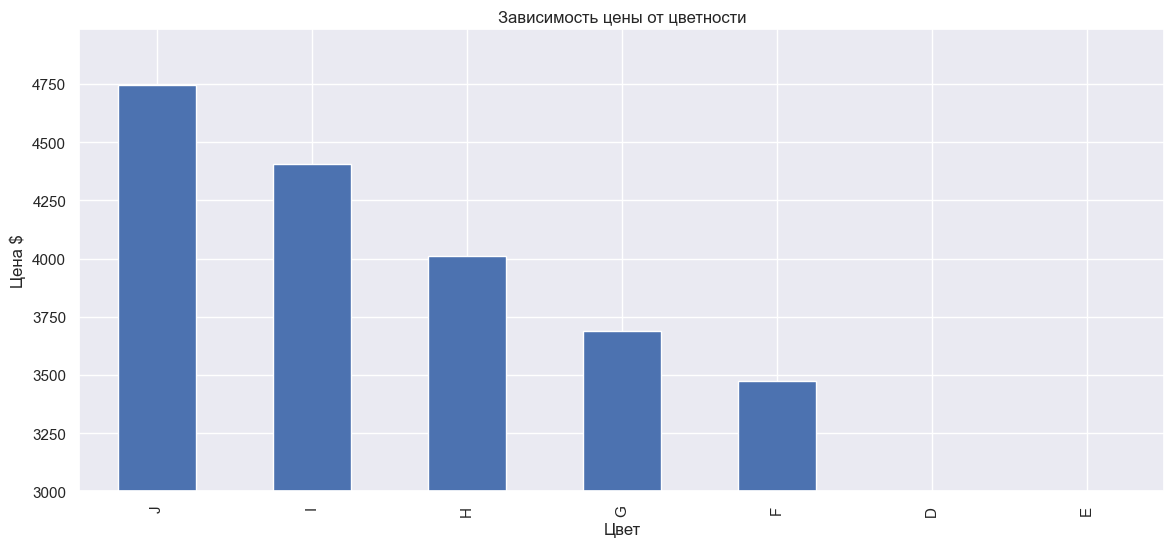

In [30]:
diamond_price.groupby('color').price.mean().sort_values(ascending = False).plot.bar(figsize=(14,6))
plt.ylim(3000)
plt.title('Зависимость цены от цветности')
plt.ylabel('Цена $')
plt.xlabel('Цвет')

На  данном графике хорошо видно, что зависимость цены от цвета существует и имеет четко выраженную тенденцию.

Посмотрим на распределение количнства бриллиантов по цвету

In [31]:
diamond_col= diamond_price.color.value_counts()
diamond_col

color
G    10866
E     9514
F     9179
H     7832
D     6600
I     5003
J     2599
Name: count, dtype: int64

Text(0, 0.5, 'Цветность')

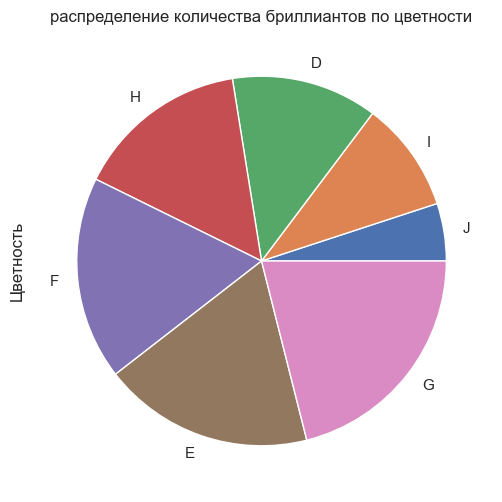

In [32]:
diamond_col.sort_values(ascending = True).plot.pie(figsize=(14,6))
plt.title('распределение количества бриллиантов по цветности')
plt.ylabel('Цветность')

Из круговой диаграммы видно, что наиболее редко встречаются бриллианты цветностью типа J и I, а наиболее распространнеым типа G. Если сопоставвить с графиками зависимости
цены от цветности то видно, что редкие бриллианты стоят намного дороже чем часто встечающиеся

Изучаем зависимость цены от чистоты бриллианта

Text(0.5, 0, 'Чистота')

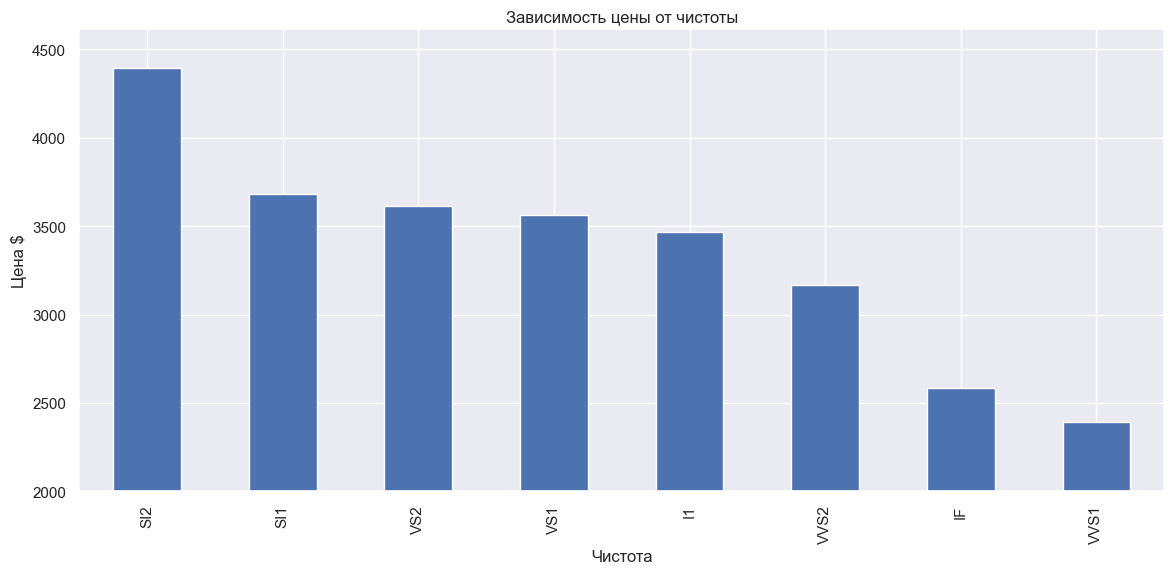

In [33]:
diamond_price.groupby('clarity').price.mean().sort_values(ascending = False).plot.bar(figsize=(14,6))
plt.ylim(2000)
plt.title('Зависимость цены от чистоты')
plt.ylabel('Цена $')
plt.xlabel('Чистота')

 На данном графике мы можем наблюдать зависимость цены от огранки и цена колеблется от 2500 до 5000"

Посмотрим на распределение количнства бриллиантов по чистоте

In [34]:
diamond_clar= diamond_price.clarity.value_counts()
diamond_clar

clarity
SI1     12555
VS2     11827
SI2      8443
VS1      7875
VVS2     4981
VVS1     3596
IF       1750
I1        566
Name: count, dtype: int64

Text(0, 0.5, 'Чистота')

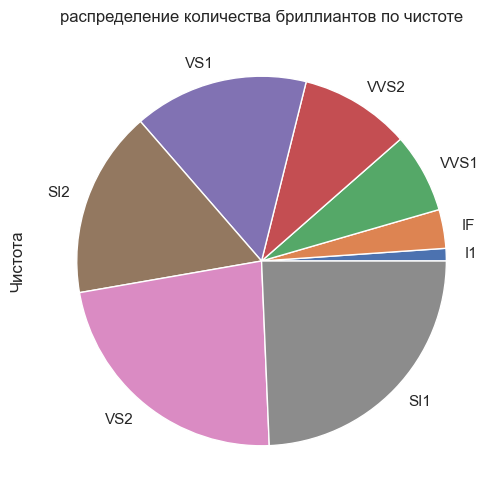

In [35]:
diamond_clar.sort_values(ascending = True).plot.pie(figsize=(14,6))
plt.title('распределение количества бриллиантов по чистоте')
plt.ylabel('Чистота')

Из круговой диаграммы видно, что наиболее редко встречаются бриллианты чистоты типа I1, IF и WS1, а наиболее распространнеым типа SI1 и VS2. Если сопоставвить с графиками зависимости цены от чистоты то видно, что в данном случае нет прямой зависимости от клоличества бриллиантов с определенной чистотой

Посмотрим по каким ценам в основном продаютя бриллианты

Text(0.5, 0, 'Цена $')

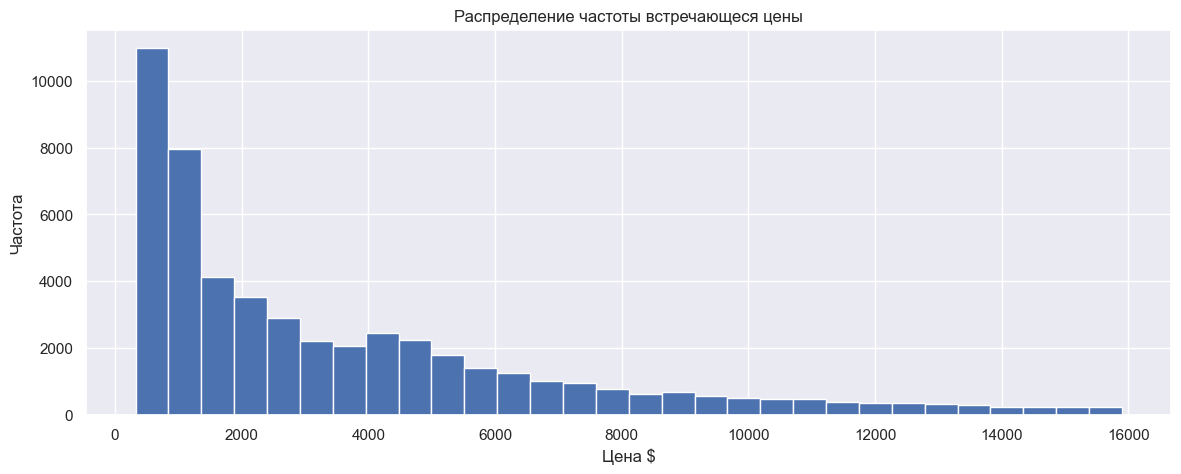

In [36]:
diamond_price.price[diamond_price.price !=0].plot.hist(bins = 30, figsize = (14,5))
plt.title('Распределение частоты встречающеся цены')
plt.ylabel('Частота')
plt.xlabel('Цена $')

 Из этой гистограммы мы можем сделать вывод, что основная масса бриллиантов продается по цене в пределах до 2500$

Т.к. мы видим слабую зависимость цены от глубину (depth) и "стола" (table) то удалим данные столбцы. Целевой переменной назначим цену бриллиантов (price)

In [37]:
X = diamond_price.drop(['price', 'table', 'depth'],axis=1)
y=diamond_price['price']

В связи с большим количеством выбросов используем RobustScaler(). Этот масштабатор удаляет медиану и масштабирует данные в соответствии с диапазоном квантилей (по умолчанию используется IQR: межквартильный диапазон). IQR - это диапазон между 1-м квартилем (25-й квантиль) и 3-м квартилем (75-й квантиль).

Центрирование и масштабирование происходят независимо для каждого объекта путем вычисления соответствующей статистики по выборкам в обучающем наборе. Медианный и межквартильный диапазон затем сохраняются для использования в последующих данных с помощью transform метода.

Стандартизация набора данных является общим требованием для многих оценщиков машинного обучения. Обычно это делается путем удаления среднего значения и масштабирования до единичной дисперсии. Однако выбросы часто могут отрицательно влиять на среднее значение выборки / дисперсию. В таких случаях медиана и межквартильный диапазон часто дают лучшие результаты. Для модели используем RandomForestRegressor. Это метаоценщик, который соответствует ряду классифицирующих деревьев решений в различных подвыборках набора данных и использует усреднение для повышения точности прогнозирования и контроля над подгонкой. Размер подвыборки регулируется max_samplesпараметром if bootstrap=True(по умолчанию), в противном случае для построения каждого дерева используется весь набор данных. В качестве метрики возьмем r2_score

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [39]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 1. Определяем порядок категорий от худшего к лучшему (или наоборот, главное - сохранить иерархию)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# 2. Создаем кодировщик для категориальных признаков
ordinal_encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])

# 3. Создаем ColumnTransformer, чтобы применить кодирование только к нужным столбцам
# (Предполагаем, что остальные столбцы в X - числовые)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ordinal_encoder, ['cut', 'color', 'clarity'])
    ],
    remainder='passthrough' # Остальные столбцы оставляем без изменений
)

acc=[]
for i in [0, 1, 2, 3, 4, 5, 42]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    
    # Сначала применяем кодирование категорий
    X_train_encoded = preprocessor.fit_transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)
    
    # Теперь применяем масштабирование
    mms = RobustScaler()
    X_train_scaled = mms.fit_transform(X_train_encoded)
    X_test_scaled = mms.transform(X_test_encoded)
    
    model = RandomForestRegressor(n_estimators=100, min_samples_leaf=3, random_state=1)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc.append(r2_score(y_test, y_pred))

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Сначала применяем кодирование категориальных признаков
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Теперь применяем масштабирование к уже закодированным данным
mms = RobustScaler()
X_train_scaled = mms.fit_transform(X_train_encoded)
X_test_scaled = mms.transform(X_test_encoded)

# Обучаем модель на масштабированных данных
model = RandomForestRegressor(n_estimators=100, min_samples_leaf=3, random_state=42)
model.fit(X_train_scaled, y_train)

# Предсказываем на масштабированных тестовых данных
y_pred = model.predict(X_test_scaled)
acc.append(r2_score(y_test, y_pred))

In [41]:
acc_vals = np.array(acc)
acc_vals

array([0.98280049, 0.98252771, 0.98407228, 0.98197482, 0.98373929,
       0.98377565, 0.9827643 , 0.98272394])

In [42]:
print(f"Average Accuracy: {acc_vals.mean()}   Standard Deviation in the accuracies: {acc_vals.std()}")

Average Accuracy: 0.9830473099806362   Standard Deviation in the accuracies: 0.0006824300277376071
